https://github.com/BNN-UPC/ignnition/tree/main/examples/Routenet

https://github.com/BNN-UPC/GNNetworkingChallenge/tree/2021_Routenet_iGNNition/code

### Go to the second part to train the model

In [1]:
import ignnition
import json
from networkx.readwrite import json_graph
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import tensorflow as tf

In [2]:
import sem
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
sns.set_style("whitegrid")
import random
import pandas as pd
import io

## Example (to generate multiple scenrios we put the functions below in the migrate.py file)

### Generate data to use with Ignnition

In [3]:
# Load files
#relative path
nodes = pd.read_csv('ns-3-dev/nodes.txt', sep='\t')    #ID	QueueDiscType	QueueDiscSizePackets
flows = pd.read_csv('ns-3-dev/flows.txt', sep='\t')    #ID	SrcNode	DstNode	DataRate(bps)	Delay(s)
links = pd.read_csv('ns-3-dev/links.txt', sep='\t')

FileNotFoundError: [Errno 2] No such file or directory: 'ns-3-dev/nodes.txt'

In [ ]:
G = nx.DiGraph()  # or Graph() for undirected

# Add nodes
for _, row in nodes.iterrows():
    G.add_node(row['ID'], type=row.get('QueueDiscType', -1), buffer_size=row.get('QueueDiscSizePackets', -1))

# Add edges with link features
for _, row in links.iterrows():
    G.add_edge(row['SrcNode'], row['DstNode'],
               bandwidth=row.get('DataRate(bps)', -1),
               delay=row.get('Delay(s)', -1)
               )


In [ ]:
# Create directed graph
G = nx.DiGraph()  # or Graph() for undirected

# --- Normalize node IDs ---
# Ensure IDs are unique and consistent (convert to int if possible, else keep as str)
node_id_map = {}
for i, raw_id in enumerate(nodes['ID']):
    try:
        node_id_map[raw_id] = int(raw_id)
    except (ValueError, TypeError):
        node_id_map[raw_id] = str(raw_id)

# --- Add nodes ---
for _, row in nodes.iterrows():
    node_id = node_id_map[row['ID']]
    G.add_node(
        node_id,
        QueueDiscType=row.get('QueueDiscType', -1),
        QueueDiscSizePackets=row.get('QueueDiscSizePackets', -1)
    )

# --- Add edges ---
for _, row in links.iterrows():
    SrcNode = node_id_map.get(row['SrcNode'], row['SrcNode'])
    DstNode = node_id_map.get(row['DstNode'], row['DstNode'])

    G.add_edge(
        SrcNode, DstNode,
        DataRate_bps=row.get('DataRate(bps)', -1),
        Delay_s=row.get('Delay(s)', -1)
    )


Visualization

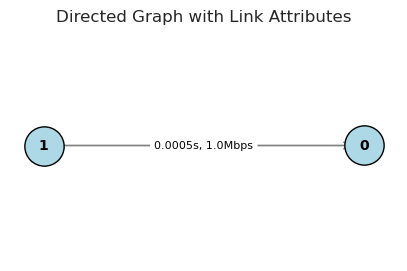

In [ ]:
plt.figure(figsize=(5, 3))

# Choose a layout
pos = nx.circular_layout(G)  # Try: kamada_kawai_layout, circular_layout, etc.

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=800, edgecolors="black")

# Draw edges
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=12, edge_color="gray")

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Extract and draw edge labels (e.g., Delay_s or DataRate_bps)
edge_labels = {
    (u, v): f"{d['Delay_s']}s, {d['DataRate_bps']/1e6:.1f}Mbps"
    for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Directed Graph with Link Attributes")
plt.axis("off")
plt.show()


In [ ]:
parser_graph = json_graph.node_link_data(G)
with open('data.json', 'w') as json_file:
            json.dump(parser_graph, json_file)

### Transform the graph into a hypergraph

Extract flows metrics into a dataframe to construct after the path entities

In [ ]:
import pandas as pd

# Read the flow file
flows = pd.read_csv("ns-3-dev/flows.txt", sep=r"\s+")  # adjust separator if needed

# Map IPs to node IDs
#change this when muliple nodes and multiple links
ip_to_node = {"10.1.1.1": 0, "10.1.1.2": 1}

# Add src_node and dst_node columns
flows["src_node"] = flows["SrcIP"].map(ip_to_node)
flows["dst_node"] = flows["DstIP"].map(ip_to_node)

# Generate flow entities (like in your example)
flow_entities = []
for idx, row in flows.iterrows():
    flow_entities.append({
        "FlowID": row['FlowID'],
        "entity": "path",
        "src_node": row["src_node"],
        "dst_node": row["dst_node"],
        "MeanThroughput(bps)": row["MeanThroughput(bps)"],
        "TxPackets": row["TxPackets"],
        "MeanDelay(s)": row["MeanDelay(s)"]
    })

# Convert to DataFrame if needed
flow_entities_df = pd.DataFrame(flow_entities)

flow_entities_df.head(2)


,FlowID,entity,src_node,dst_node,MeanThroughput(bps),TxPackets,MeanDelay(s)
0,1,path,0,1,9467.57,150,0.330401
1,2,path,0,1,19677.20,246,0.306566


In [ ]:
def network_to_hypergraph(network_graph, traffic_df):
        G = nx.DiGraph(network_graph)
        #R = routing_matrix
        flows= traffic_df
        #D = performance_matrix
        #P = port_stats
        D_G = nx.DiGraph()
        for src in range(G.number_of_nodes()):
            for dst in range(G.number_of_nodes()):
                if src != dst:
                     #Add link nodes to the hypergraph
                     #Note: queues stats are in the link node features
                     if G.has_edge(src, dst):
                        D_G.add_node('link_{}_{}'.format(src, dst),
                                    entity='link',
                                    DataRate_bps=G.edges[src, dst]['DataRate_bps'],
                                    Delay_s=G.edges[src, dst]['Delay_s'])#occupancy=P[src][dst]['qosQueuesStats'][0]['avgPortOccupancy'] /
                                            #G.nodes[src]['queueSizes'])
                       
                        # Add paths nodes to the hypergraph
                        relevant_flows = flows[(flows["src_node"] == src) & (flows["dst_node"] == dst)]

                        for _, flow in relevant_flows.iterrows():
                            if flow["MeanThroughput(bps)"] != 0 and flow["TxPackets"] != 0:
                                D_G.add_node(
                                    f"path_{src}_{dst}_{flow['FlowID']}",
                                    entity="path",
                                    MeanThroughput_bps=flow["MeanThroughput(bps)"],
                                    TxPackets=flow["TxPackets"],
                                    MeanDelay_s=flow["MeanDelay(s)"]
                                )
                                f_id=flow['FlowID']
                                #Add edges between flows and links
                                #change this when you have the routing matrix
                                D_G.add_edge('path_{}_{}_{}'.format(src, dst, f_id), 'link_{}_{}'.format(src, dst))#change when rotuing available
                                D_G.add_edge('link_{}_{}'.format(src, dst), 'path_{}_{}_{}'.format(src, dst, f_id))
        D_G.remove_nodes_from([node for node, out_degree in D_G.out_degree() if out_degree == 0])
        return D_G

                        

In [ ]:
D_G=network_to_hypergraph(G, flow_entities_df)

Visualization

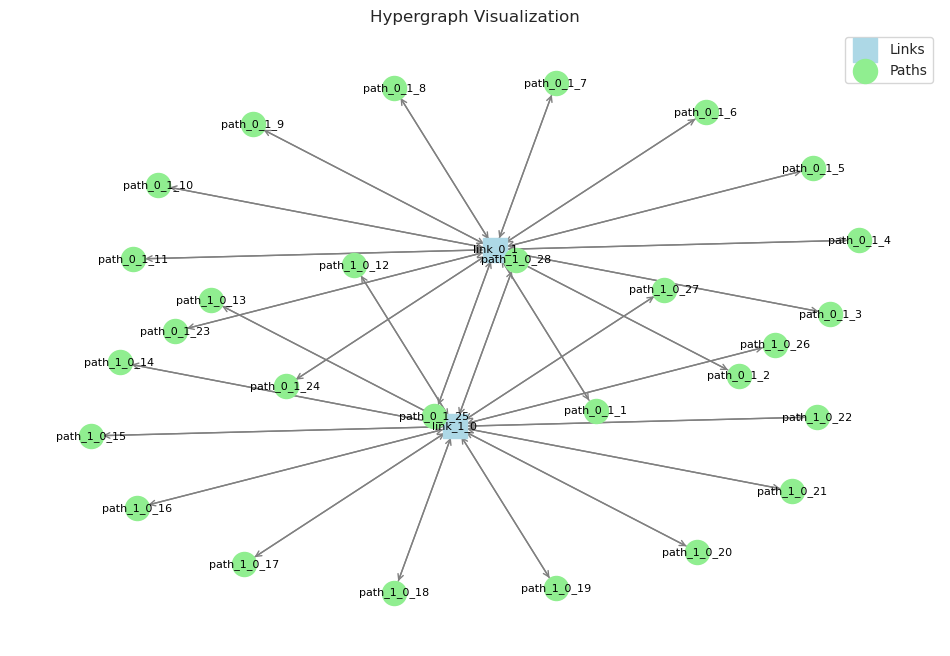

In [ ]:
# Assume D_G is your hypergraph returned by network_to_hypergraph
plt.figure(figsize=(12, 8))

# Separate nodes by type (link vs path)
link_nodes = [n for n, d in D_G.nodes(data=True) if d.get("entity") == "link"]
path_nodes = [n for n, d in D_G.nodes(data=True) if d.get("entity") == "path"]

# Layout for better visualization
#pos = nx.spring_layout(D_G, seed=42)  # or use nx.kamada_kawai_layout(D_G)
pos=nx.kamada_kawai_layout(D_G) #pos=nx.circular_layout(D_G)

# Draw nodes
nx.draw_networkx_nodes(D_G, pos, nodelist=link_nodes, node_color="lightblue", node_shape="s", label="Links")
nx.draw_networkx_nodes(D_G, pos, nodelist=path_nodes, node_color="lightgreen", node_shape="o", label="Paths")

# Draw edges
nx.draw_networkx_edges(D_G, pos, arrowstyle="->", arrowsize=10, edge_color="gray", width=1)

# Draw labels
nx.draw_networkx_labels(D_G, pos, font_size=8)

plt.legend(scatterpoints=1)
plt.title("Hypergraph Visualization")
plt.axis("off")
plt.show()


## Train the model

In [25]:
model = ignnition.create_model(model_dir='./')
model.computational_graph()
model.train_and_validate()


Processing the described model...
---------------------------------------------------------------------------

Creating the GNN model...
---------------------------------------------------------------------------

Generating the computational graph... 
---------------------------------------------------------------------------

Starting the training and validation process...
---------------------------------------------------------------------------

Your model is running on 1 CPU.


Epoch 1/5
100/100 [==============================] - 24s 95ms/step - loss: 8357817.0000 - mean_absolute_error: 87.6184 - val_loss: 0.0948 - val_mean_absolute_error: 0.1737


Epoch 2/5
100/100 [==============================] - 4s 39ms/step - loss: 946390.5625 - mean_absolute_error: 23.3942 - val_loss: 0.0690 - val_mean_absolute_error: 0.1357


Epoch 3/5
100/100 [==============================] - 4s 39ms/step - loss: 0.0405 - mean_absolute_error: 0.1204 - val_loss: 0.0766 - val_mean_absolute_error: 0.1240


Epoch 4/5
100/100 [==============================] - 4s 38ms/step - loss: 9150.1240 - mean_absolute_error: 1.5584 - val_loss: 0.0666 - val_mean_absolute_error: 0.1534


Epoch 5/5
100/100 [==============================] - 4s 38ms/step - loss: 7190.2085 - mean_absolute_error: 1.3900 - val_loss: 0.0755 - val_mean_absolute_error: 0.1904


### Evaluation


https://github.com/BNN-UPC/ignnition/blob/main/examples/Routenet/predict.py

In [26]:
prediction=model.predict()


Starting to make the predictions...
---------------------------------------------------------



In [27]:
convert_to_np = []
for elem in prediction:
    convert_to_np.append(elem.numpy())
'''
    with open('Results.pkl', 'wb') as f:
        pickle.dump(convert_to_np, f)
'''

"\n    with open('Results.pkl', 'wb') as f:\n        pickle.dump(convert_to_np, f)\n"

In [28]:
mean_error_per_data=[a.mean() for a in convert_to_np]

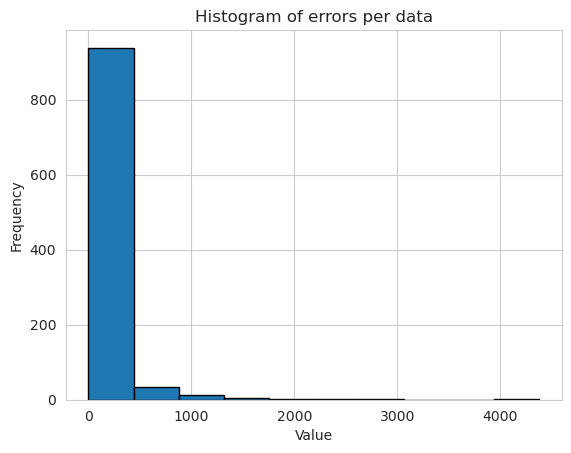

In [29]:

plt.hist(mean_error_per_data, bins=10, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of errors per data')
plt.show()

In [18]:
mean_of_means = np.mean([a.mean() for a in convert_to_np])
print("Mean of means:", mean_of_means)

Mean of means: 0.19423245
